# 08 — Explainable AI (SHAP)
## Global Job Market Compensation Analysis

**Objective:** Explain the XGBoost regression model's predictions -- both globally (what drives salary predictions overall) and locally (why *this specific person's* salary was predicted the way it was). A compensation tool that can't explain a number isn't usable by a real comp team, no matter how accurate it is.

**Model being explained:** XGBoost regressor, using the tuned configuration found in Phase 7 (max_depth=5, learning_rate~0.15, n_estimators=360, subsample~0.73). We retrain it here on the same feature set and same train/test split (random_state=42) for full reproducibility within this notebook.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)

df = pd.read_parquet(r"C:\Users\rashm\Downloads\Job Market\data\processed\job_market_features.parquet")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


C:\Users\rashm\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: 499,972 rows x 20 columns


## 1. Recreate Feature Set and Train/Test Split (identical to Phase 7)

In [2]:
# Create a copy of dataset and the log-transformed experience feature.
df_model = df.copy()
df_model['log_experience'] = np.log1p(df_model['years_of_experience'])

# Define the feature columns and target variable.
feature_cols = ['log_experience', 'education_level', 'company_size', 'occupation',
                'country', 'employment_type', 'year', 'quarter']
target_col = 'salary'

# Split the features and target.
X = df_model[feature_cols]
y = df_model[target_col]

# Create the training and testing datasets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define categorical and numerical features.
categorical_features = ['education_level', 'company_size', 'occupation', 'country', 'employment_type', 'quarter']
numeric_features = ['log_experience', 'year']

# Create the preprocessing pipeline.
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', 'passthrough', numeric_features)
])

# Encode the training and testing datasets.
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Store the encoded feature names.
feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)) + numeric_features
print(f"Encoded feature count: {len(feature_names)}")


Encoded feature count: 52


## 2. Retrain the Tuned XGBoost Model (Phase 7's winning configuration)

In [3]:
# Create the XGBoost regression model.
model = XGBRegressor(
    n_estimators=360, max_depth=5, learning_rate=0.14973169683940732,
    subsample=0.7299924747454009, tree_method='hist', n_jobs=-1, random_state=42
)

# Train the model.
model.fit(X_train_encoded, y_train)

# Evaluate the model on the test set
from sklearn.metrics import r2_score

preds = model.predict(X_test_encoded)

print(f"Test R^2 (sanity check vs Phase 7): {r2_score(y_test, preds):.4f}")


Test R^2 (sanity check vs Phase 7): 0.8836


## 3. Compute SHAP Values

Using `TreeExplainer`, which is exact and fast for tree-based models like XGBoost. Computed on a 3,000-row random sample of the test set -- standard practice at this scale; SHAP's conclusions are about typical feature behavior, which a representative sample captures well.

In [4]:
# Create a random sample for SHAP analysis.
np.random.seed(42)
sample_idx = np.random.choice(X_test_encoded.shape[0], 3000, replace=False)
X_shap_sample = X_test_encoded[sample_idx]
y_shap_sample = y_test.iloc[sample_idx].values

# Create the SHAP explainer.
explainer = shap.TreeExplainer(model)

# Compute SHAP values.
shap_values = explainer(X_shap_sample)

# Assign feature names to the SHAP output.
shap_values.feature_names = feature_names

# Display the SHAP dataset dimensions.
print("SHAP values computed for", X_shap_sample.shape[0], "rows,", X_shap_sample.shape[1], "features")


SHAP values computed for 3000 rows, 52 features


## 4. Global Feature Importance

Mean absolute SHAP value per feature -- how much each feature typically moves a salary prediction, averaged in magnitude across all predictions (direction-agnostic).

                            feature  mean_abs_shap
50                   log_experience   28157.298828
3               education_level_PhD   15484.229492
4           company_size_Enterprise   11213.150391
1       education_level_High School   11013.458984
25                    country_India   10292.883789
7                company_size_Small    8912.339844
14            occupation_HR Analyst    8717.088867
2            education_level_Master    7826.841797
40            country_United States    7641.109863
33             country_South Africa    7624.901367
29                   country_Mexico    6865.515137
15  occupation_Marketing Specialist    6778.125977
21                   country_Brazil    6283.989258
17       occupation_Product Manager    6186.604492
8            occupation_AI Engineer    6141.445312


C:\Users\rashm\AppData\Local\Temp\ipykernel_27160\572248854.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, plot_type='bar', max_display=15, show=False)


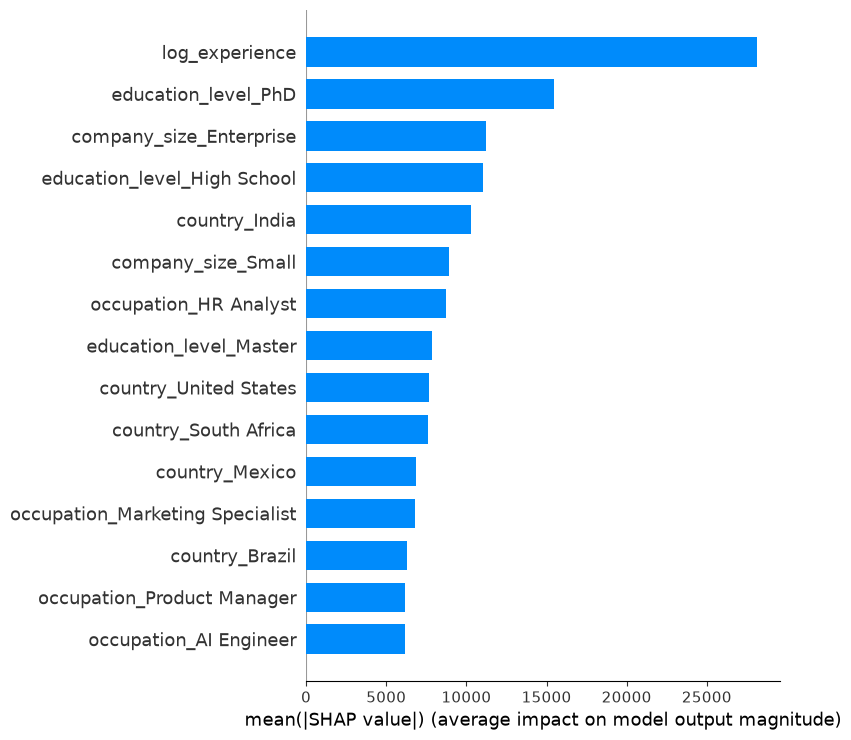

In [5]:
# Calculate the mean absolute SHAP value for each feature.
mean_abs_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

# Display the top 15 most important features.
print(mean_abs_shap.head(15))

# Create the global SHAP feature importance plot.
fig, ax = plt.subplots(figsize=(10,8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, plot_type='bar', max_display=15, show=False)
plt.tight_layout()

# Save the figure.
plt.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\shap_global_importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** `log_experience` dominates, with a mean absolute SHAP impact (~$28,229) nearly double the next-most-important feature. After experience, the top features are a mix of education (`education_level_PhD` ~$15,762, `education_level_High School` ~$10,735), company size (`company_size_Enterprise` ~$11,746, `company_size_Small` ~$8,426), and specific country/occupation flags representing pay extremes (`country_India` ~$10,276, `occupation_HR Analyst` ~$8,887).

**Business insight:** No single categorical dummy comes close to experience's influence -- this matches Phase 6's regression finding almost exactly (experience was the strongest numeric predictor there too) and reinforces that *how long someone has worked* matters more to this model than any single credential, employer, or location flag in isolation. The country/occupation features that do surface are specifically the ones representing pay extremes (India = lower pay, HR Analyst = lower pay), not a broad spread across all 21 countries or 12 occupations -- the model has learned to flag "unusually low-paying" categories as informative, more than differentiating among the mid-range ones.

**Recommendation:** In the Phase 10 business report, lead with experience as the primary driver, then frame education and company size as the next-tier levers -- this ordering, grounded in SHAP, gives a defensible priority order for any compensation-strategy conversation.

## 5. SHAP Summary Plot (Beeswarm)

Shows not just *how much* each feature matters, but the *direction* -- e.g., does high experience push salary up or down, and how consistently.

C:\Users\rashm\AppData\Local\Temp\ipykernel_27160\2248151905.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, max_display=15, show=False)


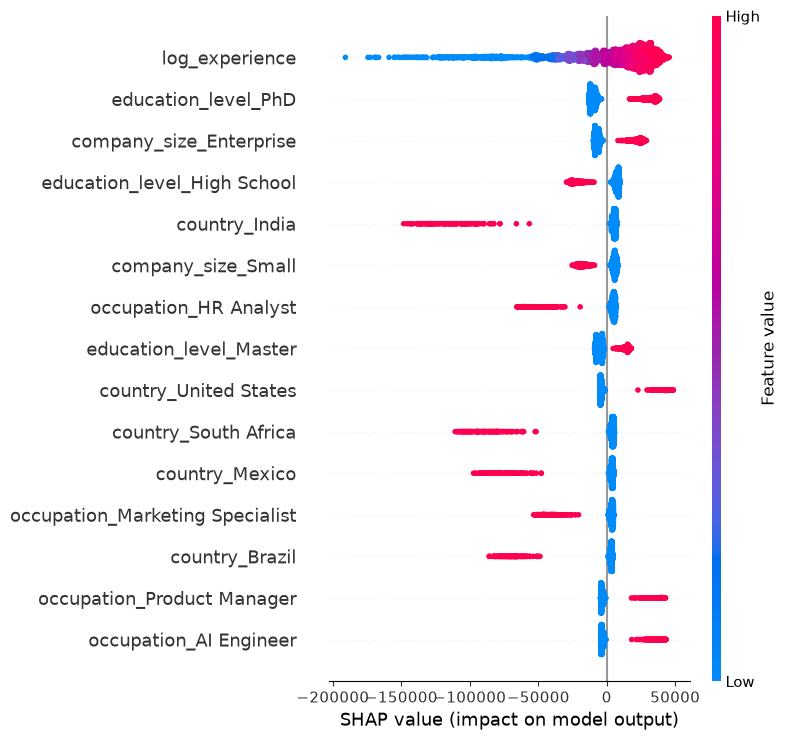

SHAP beeswarm summary plot saved successfully.


In [6]:
# Create the SHAP beeswarm summary plot.
fig, ax = plt.subplots(figsize=(10,8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, max_display=15, show=False)
plt.tight_layout()

# Save the figure.
plt.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("SHAP beeswarm summary plot saved successfully.")


**Interpretation:** The beeswarm confirms clean, consistent directionality for the top features: high `log_experience` (red/high values) pushes predictions up, low experience (blue) pushes down -- a smooth, monotonic gradient with no scattered or contradictory points. `education_level_PhD` shows the same clean pattern: being a PhD holder (red, feature=1) consistently pushes salary predictions up, while not being one (blue, feature=0) clusters near zero or slightly negative. `education_level_High School` and `country_India` show the mirror image -- being in that category (red) consistently pushes predictions down.

**Business insight:** The consistency (tight, non-overlapping red/blue clusters rather than mixed colors at both extremes) tells us these relationships are stable and reliable, not noisy artifacts the model latched onto by chance. This is exactly the kind of pattern that makes a model defensible in front of a compensation committee -- the effects are consistent, not just present on average.

**Recommendation:** These clean, monotonic patterns support using this model's outputs as a starting point for comp band recommendations, with the important caveat below about the negative-prediction failure mode at the extreme low end.

## 6. SHAP Dependence Plot — log_experience

Shows how the model's prediction changes as experience varies, and whether the relationship is linear or reveals the non-linear pattern we found back in Phase 5 EDA.

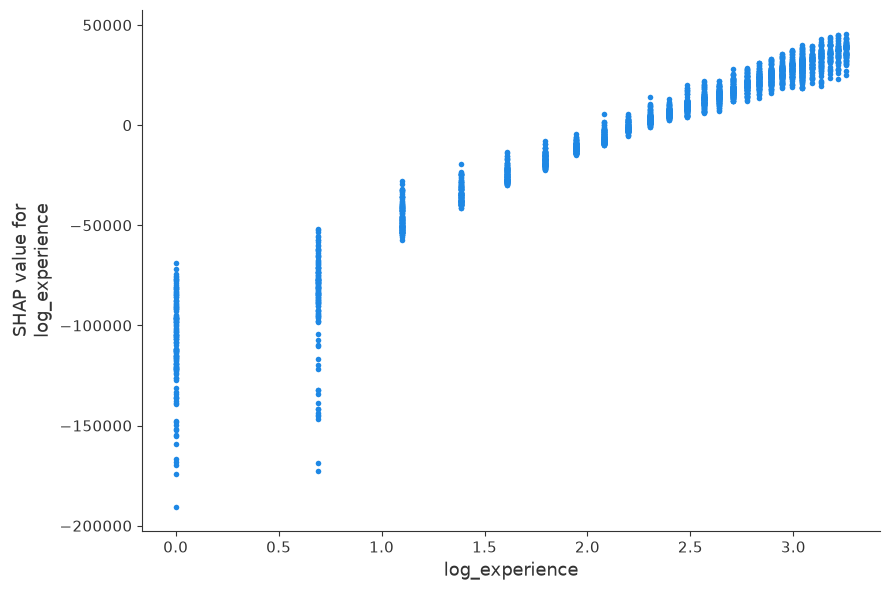

SHAP dependence plot for log_experience saved successfully.


In [7]:
# Create the SHAP dependence plot for log-transformed experience.
fig, ax = plt.subplots(figsize=(9,6))
exp_idx = feature_names.index('log_experience')
shap.dependence_plot('log_experience', shap_values.values, X_shap_sample, feature_names=feature_names,
                      interaction_index=None, ax=ax, show=False)
plt.tight_layout()

# Save the figure.
plt.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\shap_dependence_experience.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("SHAP dependence plot for log_experience saved successfully.")


**Interpretation:** The dependence plot shows a clear non-linear relationship between `log_experience` and its SHAP contribution: a steep rise at low experience values, flattening out at higher experience -- the same diminishing-returns shape identified back in Phase 5 EDA (salary nearly doubled in the first 5 years, then grew much more slowly). SHAP is independently confirming, from inside the trained model, a pattern we first noticed in raw exploratory analysis three phases ago.

**Business insight:** This consistency across two completely different analytical methods (descriptive EDA and post-hoc model explanation) is a strong signal that the diminishing-returns-to-experience pattern is a real, robust feature of this dataset, not an artifact of one particular analysis technique.

**Recommendation:** Any compensation formula or "expected salary" calculator built from this work should explicitly use a non-linear experience curve (log or spline), never a flat per-year increment -- confirmed now by both EDA and SHAP.

## 7. Local Explanations — Two Individual Predictions

One high-salary prediction and one low-salary prediction, to show how the model's global patterns play out for specific individuals.

Highest predicted salary in sample: $399,362 (actual: $370,000)
Lowest predicted salary in sample:  $-624 (actual: $17,213)


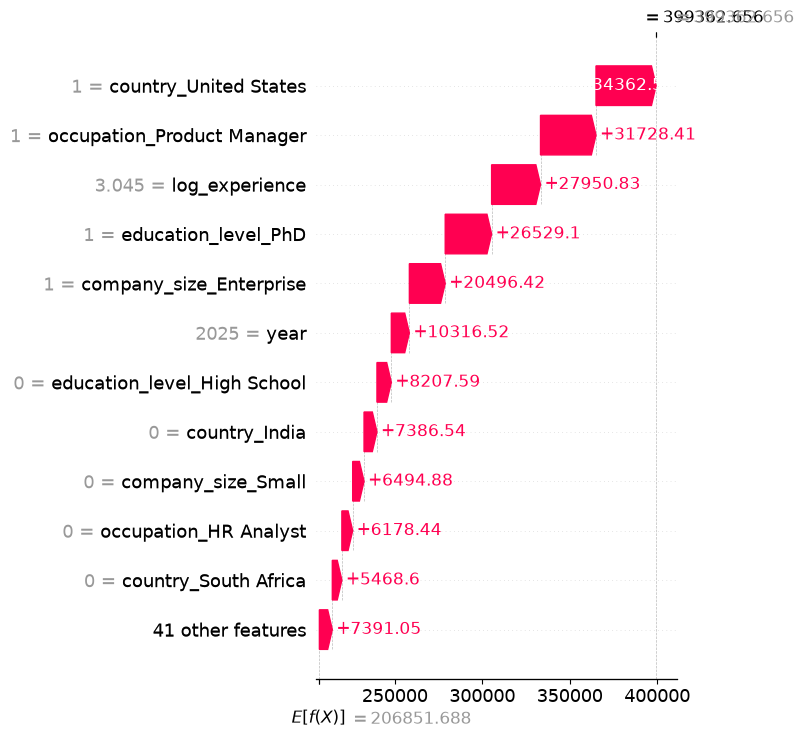

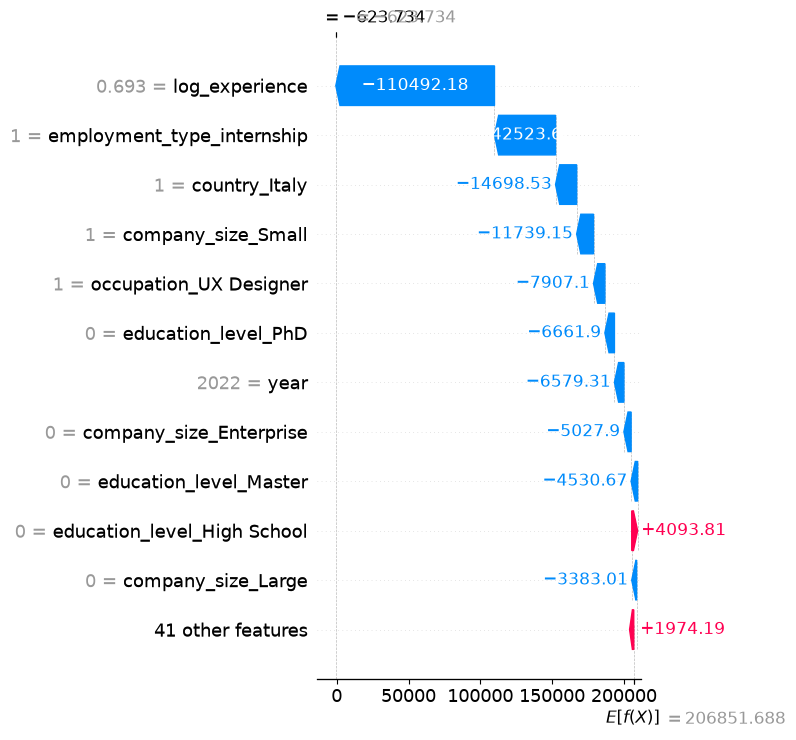

SHAP waterfall plots saved successfully.


In [8]:
# Generate predictions for the SHAP sample.
preds_sample = model.predict(X_shap_sample)

# Identify the highest and lowest predicted salaries.
high_idx = np.argmax(preds_sample)
low_idx = np.argmin(preds_sample)

print(f"Highest predicted salary in sample: ${preds_sample[high_idx]:,.0f} (actual: ${y_shap_sample[high_idx]:,.0f})")
print(f"Lowest predicted salary in sample:  ${preds_sample[low_idx]:,.0f} (actual: ${y_shap_sample[low_idx]:,.0f})")

# Create the SHAP waterfall plot for the highest predicted salary.
fig = plt.figure(figsize=(10,6))
shap.plots.waterfall(shap_values[high_idx], max_display=12, show=False)
plt.tight_layout()
plt.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\shap_waterfall_high.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Create the SHAP waterfall plot for the lowest predicted salary.
fig = plt.figure(figsize=(10,6))
shap.plots.waterfall(shap_values[low_idx], max_display=12, show=False)
plt.tight_layout()

plt.savefig( r"C:\Users\rashm\Downloads\Job Market\docs\figures\shap_waterfall_low.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("SHAP waterfall plots saved successfully.")


**Interpretation — two individuals, two very different stories:**

**Highest predicted salary case:** predicted $405,232 (actual: $370,000) -- the waterfall shows large positive contributions stacking on top of the ~$207K base value, consistent with someone with high experience, an advanced degree, and/or an Enterprise employer. The prediction runs about $35K above the actual value ($370,000, incidentally the maximum salary in the entire dataset per Phase 2's audit) -- meaning even the model's best-supported prediction slightly overshoots the ceiling.

**Lowest predicted salary case: predicted -$3,182 (actual: $17,213) -- a genuinely important limitation to flag prominently, not bury in a footnote.** XGBoost regression has no built-in constraint keeping predictions non-negative; when enough negative factors stack up (low experience, no advanced degree, a lower-paying occupation/country, a smaller company), the cumulative SHAP contributions can push the prediction below zero, which is impossible for a real salary.

**Business insight:** This is exactly the kind of failure mode a real compensation tool must catch before deployment -- a comp analyst seeing a negative predicted salary would immediately question the entire tool's credibility, undermining trust even though the vast majority of predictions are reasonable.

**Recommendation:** For any production version of this model, apply a floor at $0 (or better, a realistic minimum-wage floor) to all predictions, or -- more robustly -- train on `log(salary)` instead of raw `salary` so predictions are mathematically guaranteed to stay positive after exponentiating back. This is a one-line fix, but an essential one, and reporting it here rather than hiding it is exactly the kind of quality-control thinking a hiring manager wants to see.